Charlie Eden

5/17/2026

### Spatal Correlation

In [1]:
from spatial_correlation import *

Loading data: 2010–2020
Loaded Data for 4018 days

STEP 1: Mean Rainfall Map


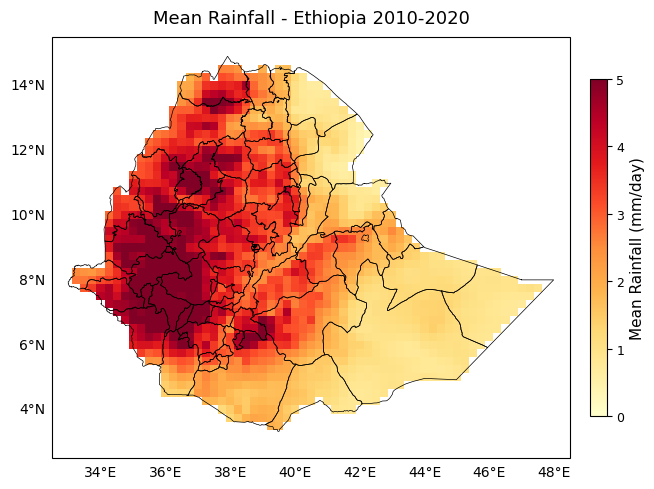

STEP 2: Spatial Correlogram


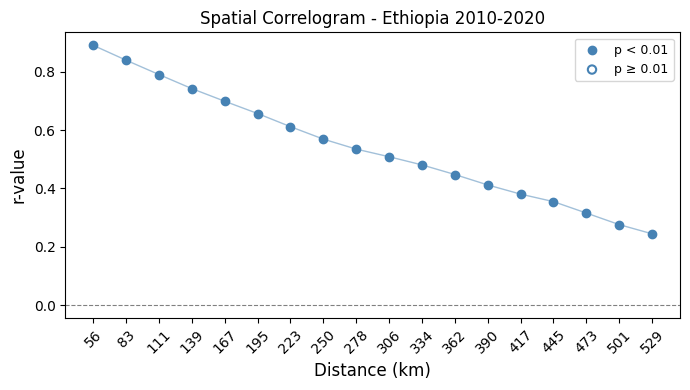

STEP 3: Detrended Empirical Variogram


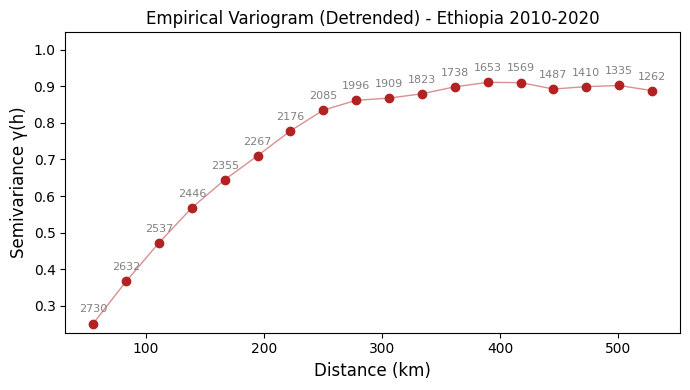

STEP 4: Spherical Model Fit
Using auto initial guess — nugget: 0.13, sill: 0.66, range: 194.81km
Spherical: nugget=0.049, sill=0.846, range=326.6km


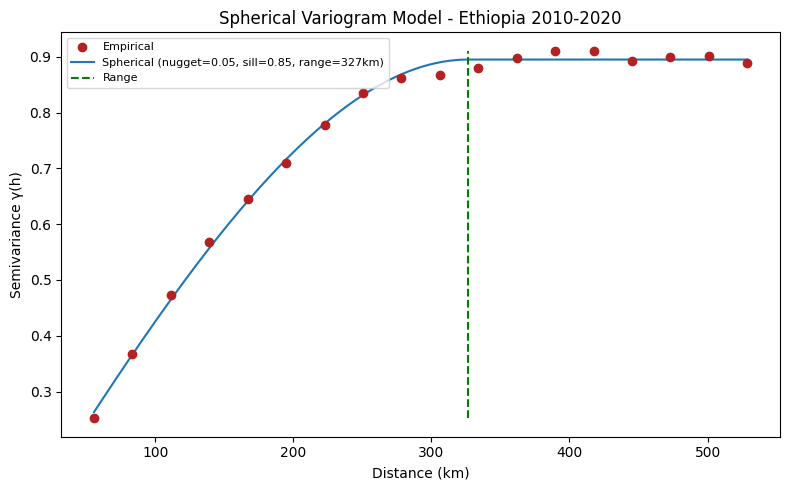

In [2]:
# Usage
results = full_spatial_analysis_pipeline(
    path_to_data='/Users/charlieeden/Desktop/Spring 2026/ds_clinic/CHIRPS_IMERG',
    start_year=2010,
    end_year=2020,
    h_range=range(2, 20),
    shp_file_path='/Users/charlieeden/Downloads/et_shapefile/Ethiopia_DIVA_GIS_State_L2_Admin_Boundaries_(1%3A7%2C000%2C000).shp',
    title_prefix='Ethiopia 2010-2020',
    alpha=0.01
)

da = results['da']
corr_df = results['corr_df']
variogram_df = results['variogram_df']
fig1, fig2, fig3, fig4 = results['figures']

In [3]:
import momp.lib.loader as loader
get_cfg = loader.get_cfg
cfg = get_cfg()

package base dir /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/momp
work_dir =  /Users/charlieeden/Code/benchmarking/test_romp_project
pkg_dir =  /Users/charlieeden/Code/benchmarking/momp
ref_model_dir =  /Users/charlieeden/Desktop/Spring 2026/ds_clinic/ROMP/docs/data/CHIRPS_IMERG
out_dir =  /Users/charlieeden/Desktop/Spring 2026/ds_clinic/ROMP/docs/demo/et/output
out_fig =  /Users/charlieeden/Desktop/Spring 2026/ds_clinic/ROMP/docs/demo/et/figure
obs_dir =  /Users/charlieeden/Desktop/Spring 2026/ds_clinic/ROMP/docs/data/CHIRPS_IMERG
thresh_file =  None
shpfile_dir =  None
nc_mask =  /Users/charlieeden/Desktop/Spring 2026/ds_clinic/ROMP/docs/demo/data/jjas_seasonal_mask_0p25.nc
Configuration validated!


In [4]:
cfg.obs_dir='/Users/charlieeden/Desktop/Spring 2026/ds_clinic/CHIRPS_IMERG'
cfg.nc_mask ="/Users/charlieeden/Downloads/jjas_seasonal_mask_0p25.nc"

In [5]:
import momp.app.onset_spatial as osp
spatial_onset = osp.spatial_onset

Loading observational rainfall data...
Detecting observed onset...
Detected resolution: 0.2 degrees


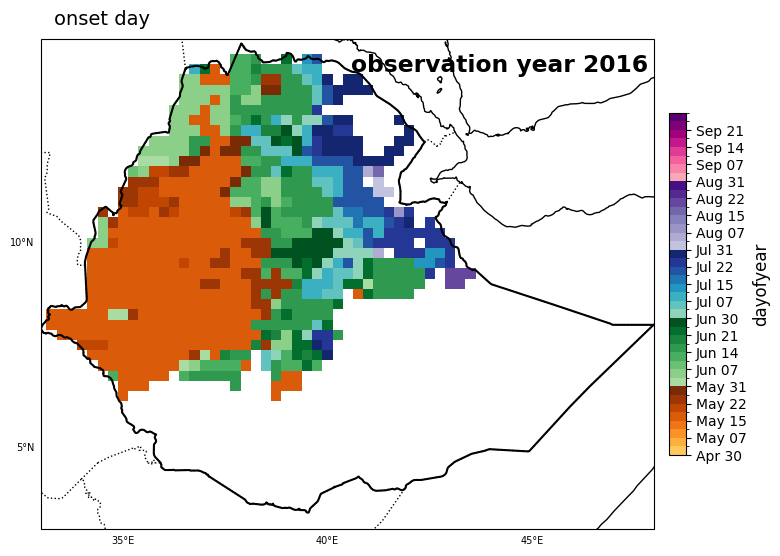

In [6]:
cfg.region = 'Ethiopia'
_ = spatial_onset(2016, **vars(cfg))

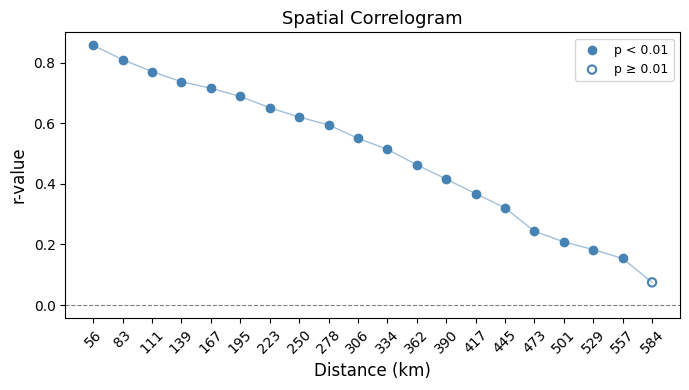

In [7]:
onset_pairs = get_dict_of_pairwise_vals(h_range=range(2,22),
                                        data=_.values)
onset_corrs = get_multiple_corr_vals(onset_pairs)
fig, ax = plot_spatial_correlogram(onset_corrs)
plt.show()

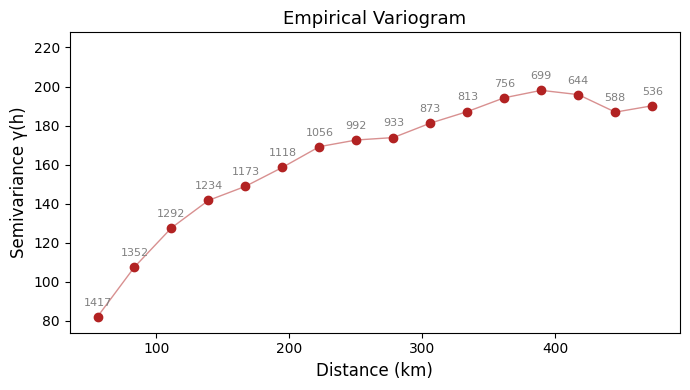

In [8]:
fig, ax, variogram_df = detrend_and_plot_variogram(range(2,18),
                                                   da=_)

Using auto initial guess — nugget: 41.06, sill: 115.91, range: 194.81km
Spherical: nugget=63.223, sill=127.927, range=358.8km


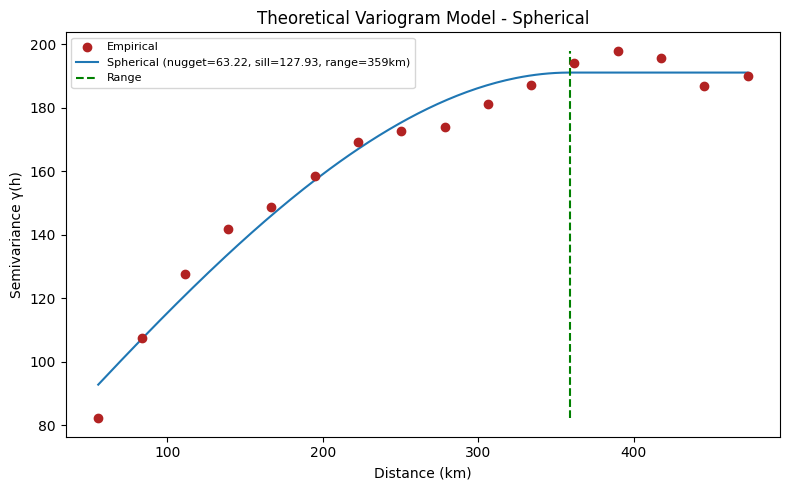

In [9]:
fig, ax, popt = plot_empirical_spherical_variogram(variogram_df)

In [10]:
krig_interp, ss = create_krig(_, popt)

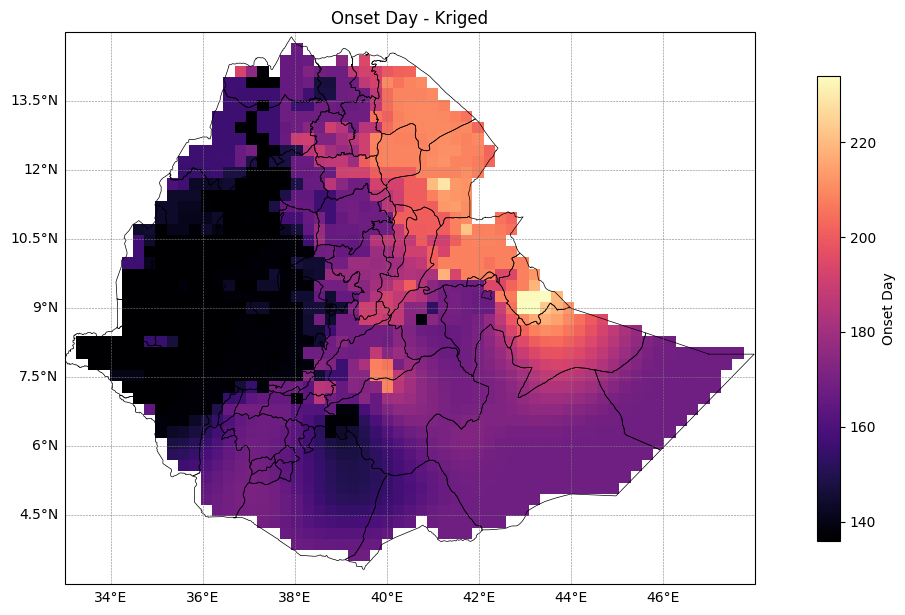

In [11]:
shp_file_path='/Users/charlieeden/Downloads/et_shapefile/Ethiopia_DIVA_GIS_State_L2_Admin_Boundaries_(1%3A7%2C000%2C000).shp'

krig_masked = plot_krig_all(da, krig_interp, shp_file_path)

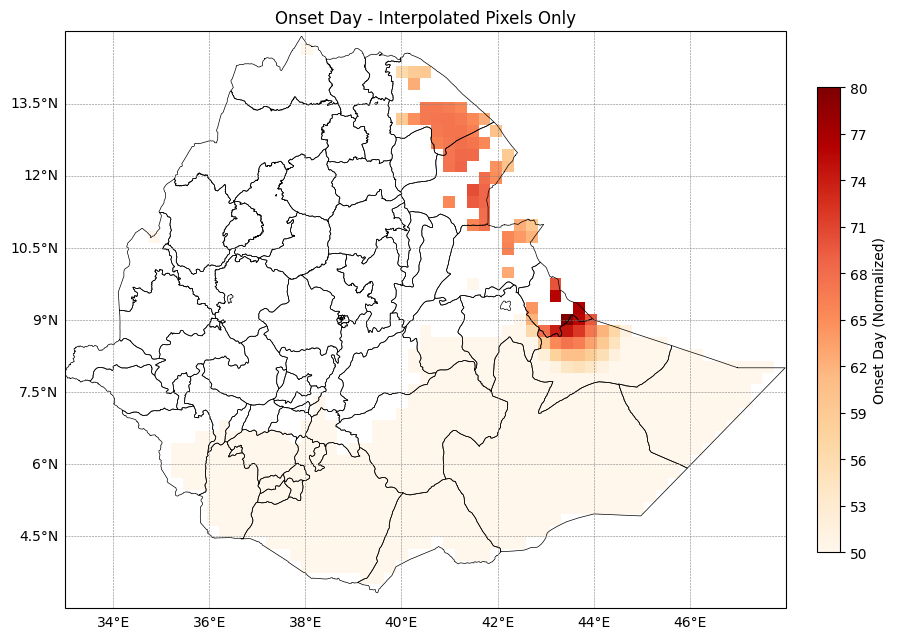

In [12]:
plot_krig_only_interp(_, krig_masked, shp_file_path)